In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [48]:
df = pd.read_csv("/content/WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [49]:
print("Shape: ", df.shape)
print("\nColumns: ", df.columns.tolist())
print("\nAttrition Breakdown: ", df['Attrition'].value_counts())
print("\nNull Values: ", df.isnull().sum().sum())

Shape:  (1470, 35)

Columns:  ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Attrition Breakdown:  Attrition
No     1233
Yes     237
Name: count, dtype: int64

Null Values:  0


In [50]:
sns.set_theme(style='whitegrid')
os.makedirs('outputs', exist_ok=True)


# Drop useless constant columns
df = df.drop(columns=['EmployeeCount','StandardHours','Over18'])

# Create numeric target column
df['Attrition_Flag'] = (df['Attrition'] == 'Yes').astype(int)

print("Shape:", df.shape)
print("\nOverall attrition rate:",
      round(df['Attrition_Flag'].mean() * 100, 1), "%")
print("\nAttrition counts:")
print(df['Attrition'].value_counts())

Shape: (1470, 33)

Overall attrition rate: 16.1 %

Attrition counts:
Attrition
No     1233
Yes     237
Name: count, dtype: int64


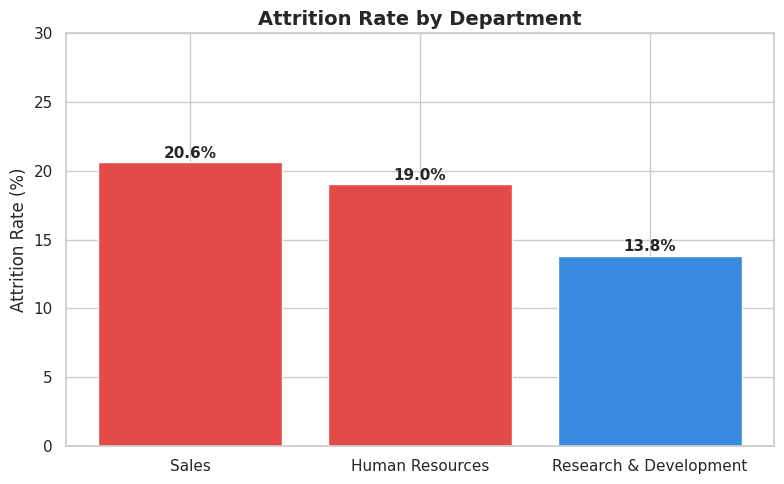

In [51]:
# Chart 1 - Attrition rate by department

dept = df.groupby('Department')['Attrition_Flag'].mean() * 100
dept = dept.sort_values(ascending=False).reset_index()
dept.columns = ['Department', 'Attrition Rate %']

fig, ax = plt.subplots(figsize=(8,5))
colors = ['#E24B4A' if x > 15 else '#378ADD'
          for x in dept['Attrition Rate %']]
bars = ax.bar(dept['Department'],
              dept['Attrition Rate %'], color=colors)

for bar, val in zip(bars, dept['Attrition Rate %']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center',
            fontsize=11, fontweight='bold')

ax.set_title('Attrition Rate by Department',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Attrition Rate (%)')
ax.set_ylim(0, 30)
plt.tight_layout()
plt.savefig('outputs/attrition_by_dept.png', dpi=150)
plt.show()

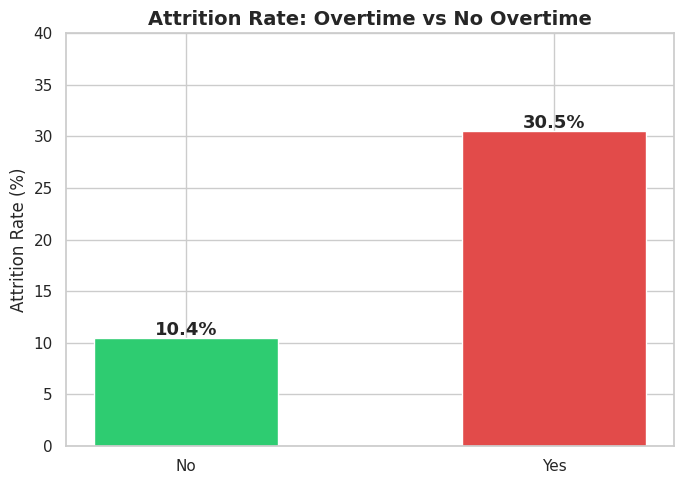

In [52]:
# Chart 2 - Overtime impact

ot = df.groupby('OverTime')['Attrition_Flag'].mean() * 100

fig, ax = plt.subplots(figsize=(7,5))
colors = ['#2ECC71','#E24B4A']
bars = ax.bar(ot.index, ot.values,
              color=colors, width=0.5)

for bar, val in zip(bars, ot.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center',
            fontsize=13, fontweight='bold')

ax.set_title('Attrition Rate: Overtime vs No Overtime',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Attrition Rate (%)')
ax.set_ylim(0, 40)
plt.tight_layout()
plt.savefig('outputs/overtime_attrition.png', dpi=150)
plt.show()

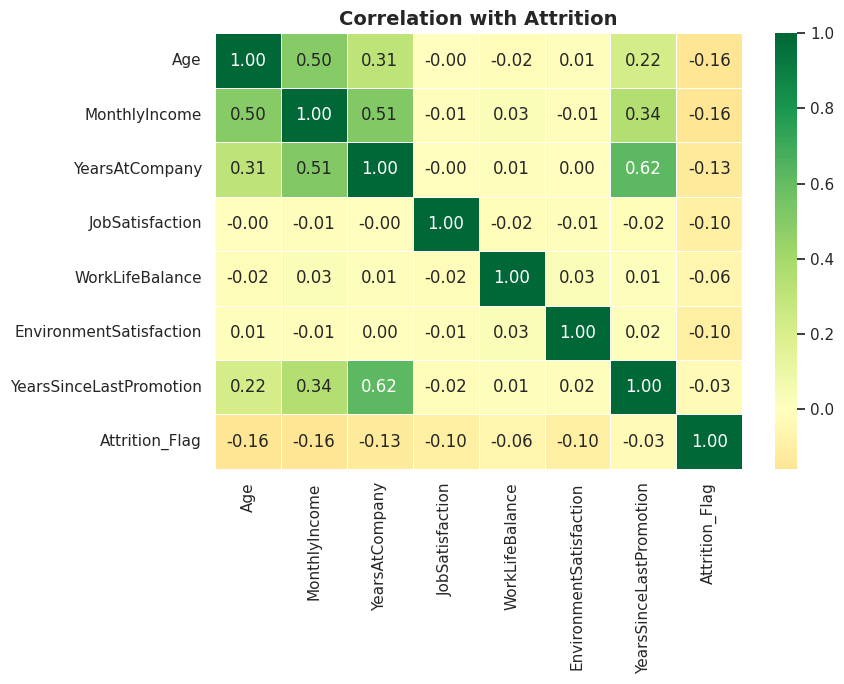

In [53]:
# Chart 3 - Correlation heatmap

numeric_cols = [
    'Age','MonthlyIncome','YearsAtCompany',
    'JobSatisfaction','WorkLifeBalance',
    'EnvironmentSatisfaction','YearsSinceLastPromotion',
    'Attrition_Flag'
]
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9,7))
sns.heatmap(corr, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0,
            linewidths=0.5, ax=ax)
ax.set_title('Correlation with Attrition',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/correlation_heatmap.png', dpi=150)
plt.show()

# Statistics

## Chi-square tests on all key variables

In [54]:
from scipy import stats

variables = [
    'OverTime', 'Department', 'JobRole',
    'Gender', 'MaritalStatus', 'BusinessTravel'
]

print("Chi-Square Test Results")
print("=" * 55)
print(f"{'Variable':<25} {'Chi2':>8} {'P-Value':>12} {'Significant?':>14}")
print("=" * 55)

for var in variables:
    ct = pd.crosstab(df[var], df['Attrition_Flag'])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    sig = "YES" if p < 0.05 else "NO"
    print(f"{var:<25} {chi2:>8.2f} {p:>12.6f} {sig:>14}")

Chi-Square Test Results
Variable                      Chi2      P-Value   Significant?
OverTime                     87.56     0.000000            YES
Department                   10.80     0.004526            YES
JobRole                      86.19     0.000000            YES
Gender                        1.12     0.290572             NO
MaritalStatus                46.16     0.000000            YES
BusinessTravel               24.18     0.000006            YES


## Point-biserial correlation for numeric variables

In [55]:
numeric_vars = [
    'MonthlyIncome', 'Age', 'YearsAtCompany',
    'JobSatisfaction', 'WorkLifeBalance',
    'YearsSinceLastPromotion', 'DistanceFromHome'
]

print("\nCorrelation with Attrition (numeric variables)")
print("=" * 55)
print(f"{'Variable':<30} {'Correlation':>12} {'P-Value':>10}")
print("=" * 55)

for var in numeric_vars:
    corr, p = stats.pointbiserialr(
        df['Attrition_Flag'], df[var]
    )
    direction = "higher=more attrition" if corr > 0 \
                else "lower=more attrition"
    print(f"{var:<30} {corr:>12.4f} {p:>10.6f}"
          f"  ({direction})")


Correlation with Attrition (numeric variables)
Variable                        Correlation    P-Value
MonthlyIncome                       -0.1598   0.000000  (lower=more attrition)
Age                                 -0.1592   0.000000  (lower=more attrition)
YearsAtCompany                      -0.1344   0.000000  (lower=more attrition)
JobSatisfaction                     -0.1035   0.000070  (lower=more attrition)
WorkLifeBalance                     -0.0639   0.014211  (lower=more attrition)
YearsSinceLastPromotion             -0.0330   0.205790  (lower=more attrition)
DistanceFromHome                     0.0779   0.002793  (higher=more attrition)


## Visualise statistical findings

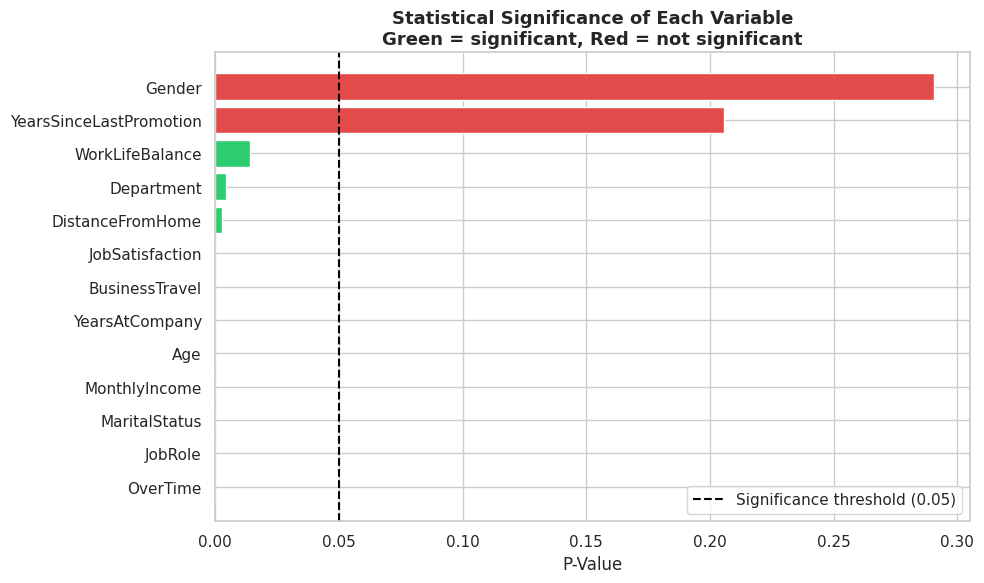

In [56]:
from scipy.stats import chi2_contingency

# P-value bar chart for all tested variables
all_vars = variables + numeric_vars
p_values = []

for var in all_vars:
    if df[var].dtype == 'object':
        ct = pd.crosstab(df[var], df['Attrition_Flag'])
        _, p, _, _ = chi2_contingency(ct)
    else:
        _, p = stats.pointbiserialr(
            df['Attrition_Flag'], df[var]
        )
    p_values.append(p)

pval_df = pd.DataFrame({
    'Variable': all_vars,
    'P_Value': p_values
}).sort_values('P_Value')

fig, ax = plt.subplots(figsize=(10,6))
colors = ['#2ECC71' if p < 0.05 else '#E24B4A'
          for p in pval_df['P_Value']]
ax.barh(pval_df['Variable'], pval_df['P_Value'],
        color=colors)
ax.axvline(0.05, color='black', linestyle='--',
           linewidth=1.5, label='Significance threshold (0.05)')
ax.set_title('Statistical Significance of Each Variable\n'
             'Green = significant, Red = not significant',
             fontsize=13, fontweight='bold')
ax.set_xlabel('P-Value')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/statistical_significance.png', dpi=150)
plt.show()

In [57]:
# Export clean data for Tableau

df.to_csv('outputs/hr_clean_for_tableau.csv', index=False)
print("Saved hr_clean_for_tableau.csv")

from google.colab import files
files.download('outputs/hr_clean_for_tableau.csv')

Saved hr_clean_for_tableau.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>